# WeatherJEPA — Kaggle Training

Clones the latest code from GitHub, downloads the ERA5 database, trains the JEPA model, and visualizes embeddings.

In [ ]:
# ============================================================
# Config -- change these, not the cells below
# ============================================================
GITHUB_REPO = "https://github.com/zariqq/weather-forecast.git"
PROJECT_DIR = "/kaggle/working/project"

PLACE = "Lidar(Tomsk)"
DB_PATH = "/kaggle/working/data.db"

TRAIN_START, TRAIN_END = "2009-01-01", "2021-12-31"
EVAL_START, EVAL_END   = "2022-01-01", "2023-12-31"

CTX_LEN = 8           # hours of context (native cadence = hourly)
EMBED_DIM = 32        # 16/32/64 -- smaller wins leaderboard
EPOCHS = 30
EVAL_EVERY = 1

# JEPA loss weights -- raise jepa + add anti_collapse if cosine similarity > 0.9
JEPA_WEIGHT = 2.0
FORECAST_WEIGHT = 0.5
ANTI_COLLAPSE_WEIGHT = 0.1   # 0.05-0.2 range, variance regularization
EMA_MOMENTUM = 0.99          # default 0.996, lower = harder JEPA task = less collapse

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU — set Settings > Accelerator to GPU T4 x2 or P100, then restart.")

CUDA available: True
GPU: Tesla T4


## 1. Clone latest code from GitHub

In [3]:
import os, shutil

if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

!git clone {GITHUB_REPO} {PROJECT_DIR}
%cd {PROJECT_DIR}
!git log --oneline -3

Cloning into '/kaggle/working/project'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 67 (delta 24), reused 58 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 5.39 MiB | 22.88 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/kaggle/working/project
9ce766c (HEAD -> main, origin/main, origin/HEAD) add anti-collapse loss, ema-momentum flag, standalone eval.py
130d287 split eval and train-eval
94692e0 update: eval loss


## 2. Install dependencies

In [4]:
!grep -vi "^torch" {PROJECT_DIR}/requirements.txt > /tmp/requirements_no_torch.txt || true
!pip install -q -r /tmp/requirements_no_torch.txt
print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.3/133.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.3/224.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.7/323.7 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 65.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 3. Download ERA5 database (~2.7 GB, cached after first run)

In [5]:
import sys
sys.path.insert(0, PROJECT_DIR)

from download_data import ensure_db

DB_PATH = ensure_db(DB_PATH)
print("DB ready at:", DB_PATH)

[download_data] /kaggle/working/data.db not found, downloading Drive folder to /kaggle/working/.drive_cache (this only needs to happen once)...


Retrieving folder contents


Processing file 1MzmrgQgVMKGBD4k0cz3fssjv_sWboVle data-challenge.db
Processing file 1IlUg2g9LF9aPsah6QVckroPV-bXMrDse pylidlight.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1MzmrgQgVMKGBD4k0cz3fssjv_sWboVle
From (redirected): https://drive.google.com/uc?id=1MzmrgQgVMKGBD4k0cz3fssjv_sWboVle&confirm=t&uuid=d5d4248a-0a15-43a5-80c5-7130142b4d25
To: /kaggle/working/.drive_cache/data-challenge.db
100%|██████████| 2.68G/2.68G [00:22<00:00, 119MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1IlUg2g9LF9aPsah6QVckroPV-bXMrDse
To: /kaggle/working/.drive_cache/pylidlight.zip
100%|██████████| 311k/311k [00:00<00:00, 92.9MB/s]
Download completed


[download_data] copied /kaggle/working/.drive_cache/data-challenge.db -> /kaggle/working/data.db
DB ready at: /kaggle/working/data.db


## 4. Train

In [6]:
!python {PROJECT_DIR}/train.py \
  --db {DB_PATH} --place "{PLACE}" \
  --train-start {TRAIN_START} --train-end {TRAIN_END} \
  --eval-start {EVAL_START} --eval-end {EVAL_END} \
  --ctx-len {CTX_LEN} --embed-dim {EMBED_DIM} --epochs {EPOCHS} \
  --jepa-weight {JEPA_WEIGHT} --forecast-weight {FORECAST_WEIGHT} \
  --anti-collapse-weight {ANTI_COLLAPSE_WEIGHT} \
  --ema-momentum {EMA_MOMENTUM} \
  --ckpt /kaggle/working/weather_jepa_last.pt \
  --ckpt-best /kaggle/working/weather_jepa.pt \
  --metrics-out /kaggle/working/rmse_metrics.json \
  --eval-every {EVAL_EVERY}


[download_data] found existing DB at /kaggle/working/data.db, skipping download
using device: cuda
[dataset] Lidar(Tomsk): 123769 timesteps, detected native cadence = 3600s (1.00h), 0.0% of intervals look like gaps
closed
train samples: 113922, eval samples: 9805, levels: 37
epoch 000  jepa=0.14875  fcst_3h=0.06841  fcst_6h=0.07944  var=0.34348 | eval RMSE_3h=0.00030  RMSE_6h=0.00033  (avg=0.00031) *
epoch 001  jepa=0.12617  fcst_3h=0.03613  fcst_6h=0.04760  var=0.24478 | eval RMSE_3h=0.00024  RMSE_6h=0.00028  (avg=0.00026) *
epoch 002  jepa=0.13872  fcst_3h=0.03098  fcst_6h=0.04275  var=0.22211 | eval RMSE_3h=0.00024  RMSE_6h=0.00029  (avg=0.00026)
epoch 003  jepa=0.14462  fcst_3h=0.02805  fcst_6h=0.04011  var=0.22673 | eval RMSE_3h=0.00023  RMSE_6h=0.00028  (avg=0.00026) *
epoch 004  jepa=0.14313  fcst_3h=0.02565  fcst_6h=0.03803  var=0.26296 | eval RMSE_3h=0.00021  RMSE_6h=0.00027  (avg=0.00024) *
epoch 005  jepa=0.14577  fcst_3h=0.02400  fcst_6h=0.03659  var=0.29974 | eval RMSE_3h=

## 5. Inspect results

Mean RMSE by horizon (kg/kg):
  3h: 0.000182
  6h: 0.000239
Embedding dim: 64
Eval range: ['2022-01-01', '2023-12-31']


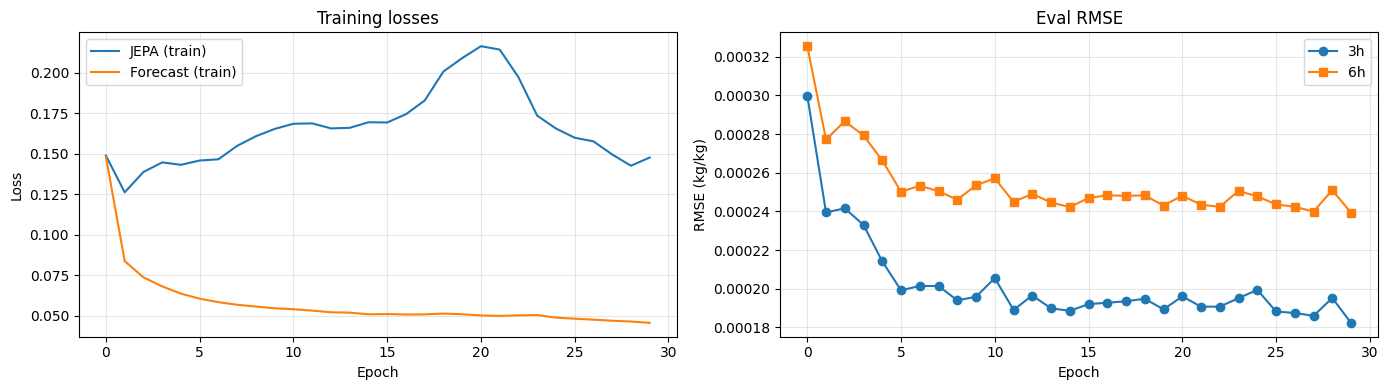

In [7]:
import json

with open("/kaggle/working/rmse_metrics.json") as f:
    metrics = json.load(f)

print("Mean RMSE by horizon (kg/kg):")
for h, v in metrics["rmse_mean_by_horizon"].items():
    print(f"  {h}h: {v:.6f}")
print(f"Embedding dim: {metrics['embed_dim']}")
print(f"Eval range: {metrics['eval_range']}")
if metrics.get("best_eval_rmse_mean"):
    print(f"Best eval RMSE (avg): {metrics['best_eval_rmse_mean']:.6f}")

# Quick loss plot
import matplotlib.pyplot as plt
history = metrics["loss_history"]
epochs = [h["epoch"] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(epochs, [h["jepa_loss"] for h in history], label="JEPA (train)")
ax1.plot(epochs, [h["forecast_loss"] for h in history], label="Forecast (train)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training losses")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Per-horizon eval RMSE (may not exist for every epoch if eval_every > 1)
eval_3h = [(h["epoch"], h["eval_rmse_3h"]) for h in history if "eval_rmse_3h" in h]
eval_6h = [(h["epoch"], h["eval_rmse_6h"]) for h in history if "eval_rmse_6h" in h]
if eval_3h:
    ax2.plot([e[0] for e in eval_3h], [e[1] for e in eval_3h], "o-", label="3h")
    ax2.plot([e[0] for e in eval_6h], [e[1] for e in eval_6h], "s-", label="6h")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("RMSE (kg/kg)")
ax2.set_title("Eval RMSE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_curves.png", dpi=100)
plt.show()

## 6. Embedding visualization (PCA / t-SNE / cosine similarity)

[download_data] found existing DB at /kaggle/working/data.db, skipping download
using device: cuda
[dataset] Lidar(Tomsk): 123769 timesteps, detected native cadence = 3600s (1.00h), 0.0% of intervals look like gaps
closed
embedding dim: 64, n samples: 1500
mean off-diagonal cosine similarity: 0.8772
Saved: /kaggle/working/embeddings_pca.png, /kaggle/working/embeddings_tsne.png, /kaggle/working/embeddings_cosine_sim.png


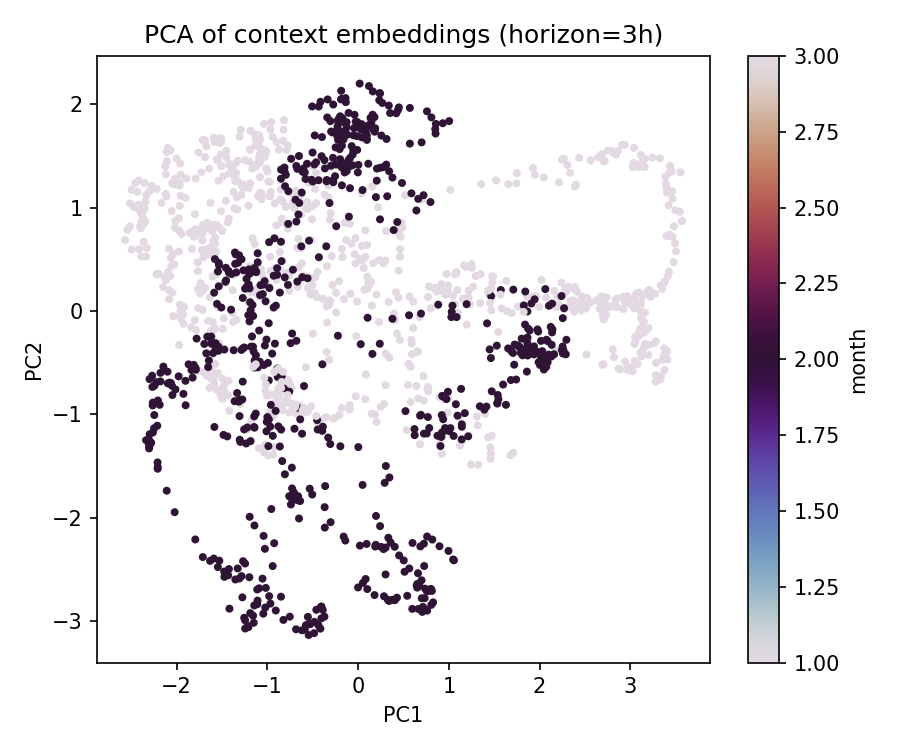

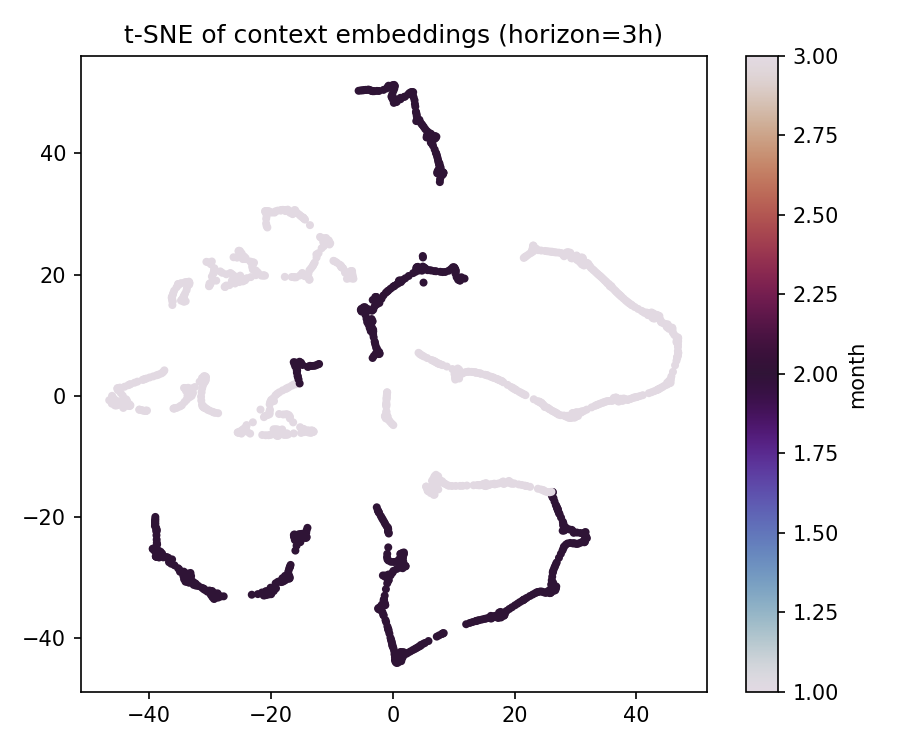

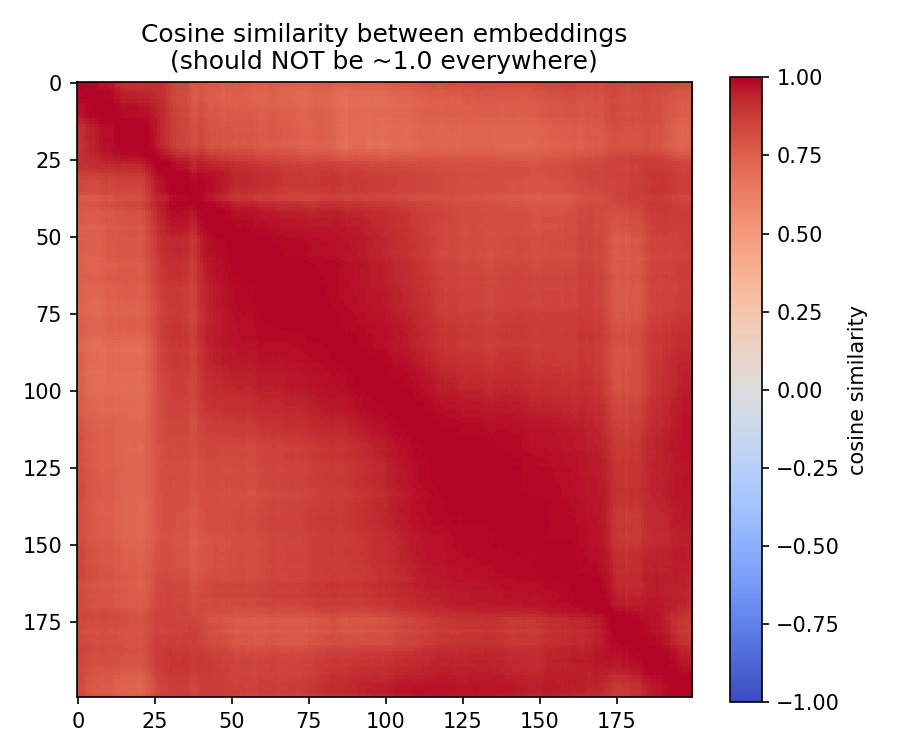

In [8]:
!python {PROJECT_DIR}/visualize_embeddings.py \
  --db {DB_PATH} --place "{PLACE}" \
  --ckpt /kaggle/working/weather_jepa.pt \
  --eval-start {EVAL_START} --eval-end {EVAL_END} \
  --horizon 3 \
  --out-prefix /kaggle/working/embeddings

from IPython.display import Image, display
display(Image("/kaggle/working/embeddings_pca.png"))
display(Image("/kaggle/working/embeddings_tsne.png"))
display(Image("/kaggle/working/embeddings_cosine_sim.png"))